In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/supply_chain_data.csv')

In [3]:
df.shape

(100, 24)

In [5]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [6]:
df.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [8]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [9]:
df.tail()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864
99,haircare,SKU99,68.517833,17,627,9185.185829,Unknown,55,8,59,...,Chennai,29,921,2,38.072899,Fail,0.346027,Rail,Route B,210.743009


# **Which product type generates highest revenue?**

In [16]:
highest_revenue = df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False).head()

In [17]:
print(highest_revenue)

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64


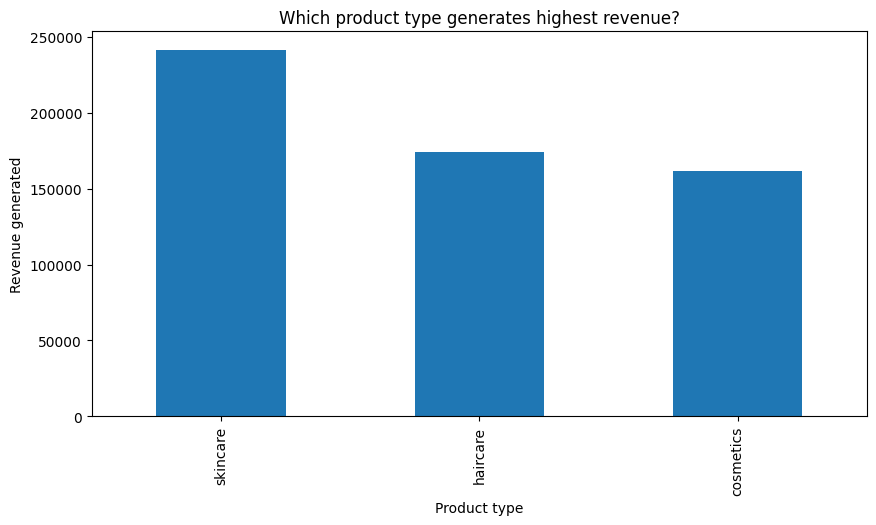

In [19]:
highest_revenue.plot(kind='bar',figsize=(10,5),title='Which product type generates highest revenue?')
plt.ylabel('Revenue generated')
plt.xlabel('Product type')
plt.show()

# **Which supplier has highest defect rate?**

In [24]:
defect_rate = df.groupby('Supplier name')['Defect rates'].sum().sort_values(ascending=False).head()

In [25]:
print(defect_rate)

Supplier name
Supplier 2    51.980503
Supplier 1    48.698002
Supplier 5    47.977350
Supplier 4    42.073153
Supplier 3    36.986790
Name: Defect rates, dtype: float64


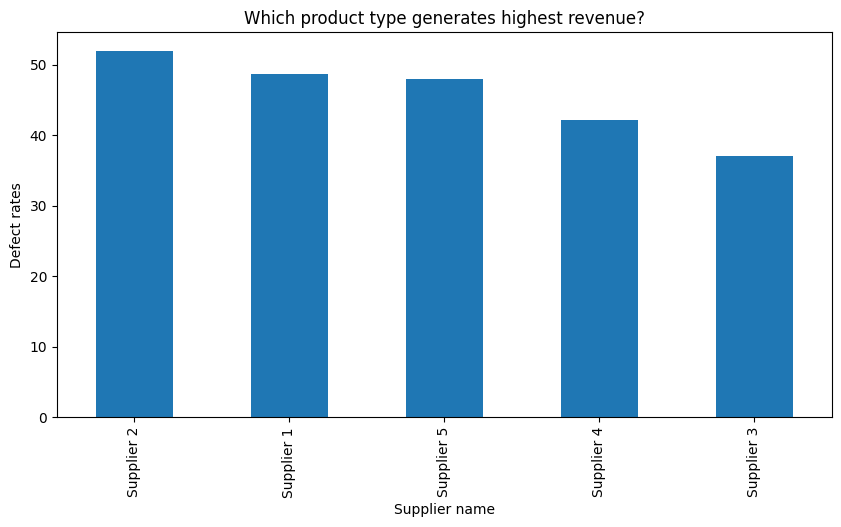

In [26]:
defect_rate.plot(kind='bar',figsize=(10,5),title='Which product type generates highest revenue?')
plt.xlabel('Supplier name')
plt.ylabel('Defect rates')
plt.show()

# **Shipping carrier performance — cost vs time**

In [39]:
shipping_performance = df.groupby('Shipping carriers')[['Shipping times','Shipping costs']].sum().sort_values('Shipping costs',ascending=False).head()

In [40]:
print(shipping_performance)

                   Shipping times  Shipping costs
Shipping carriers                                
Carrier B                     228      236.897620
Carrier C                     175      162.379457
Carrier A                     172      155.537831


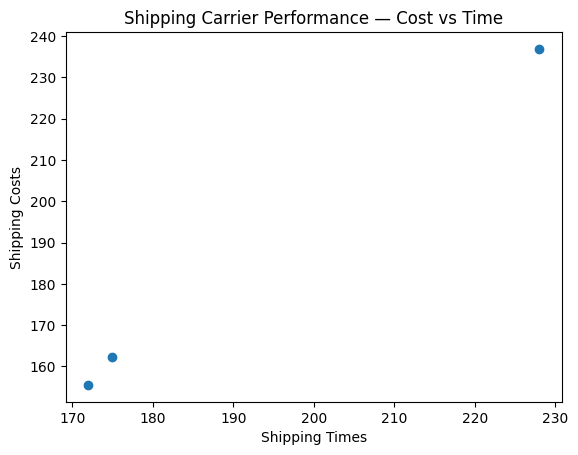

In [41]:
plt.scatter(shipping_performance['Shipping times'], shipping_performance['Shipping costs'])
plt.xlabel('Shipping Times')
plt.ylabel('Shipping Costs')
plt.title('Shipping Carrier Performance — Cost vs Time')
plt.show()

# **Which location has highest manufacturing cost?**

In [42]:
manufacturing_cost = df.groupby('Location')['Manufacturing costs'].sum().sort_values(ascending=False).head()

In [43]:
print(manufacturing_cost)

Location
Bangalore    1115.909593
Kolkata      1046.578054
Chennai      1022.900869
Mumbai        808.080426
Delhi         733.200383
Name: Manufacturing costs, dtype: float64


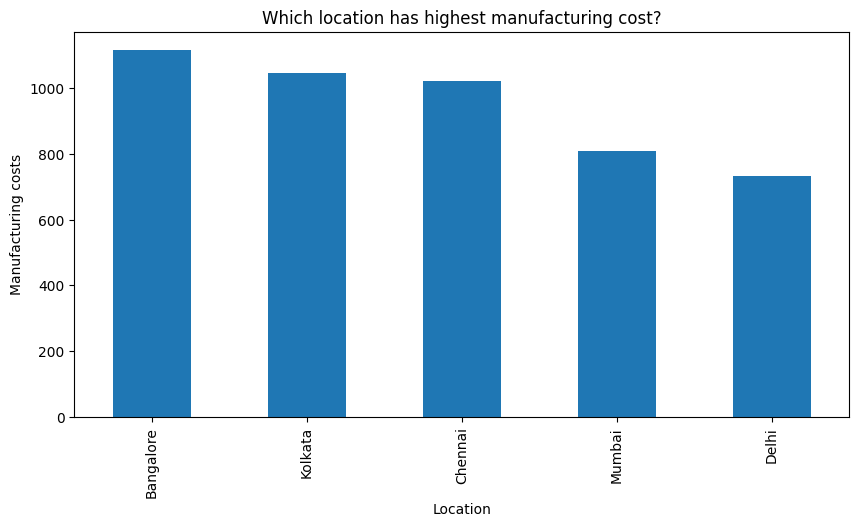

In [45]:
manufacturing_cost.plot(kind='bar',figsize=(10,5),title='Which location has highest manufacturing cost?')
plt.ylabel('Manufacturing costs')
plt.xlabel('Location')
plt.show()

# **Stock levels vs Lead time relation**

In [61]:
level_vs_lead = df.groupby('Stock levels')['Lead times'].mean().sort_values(ascending=False).head(10)
print(level_vs_lead)

Stock levels
36    29.0
78    29.0
92    29.0
14    27.0
22    27.0
73    26.5
57    26.5
96    26.5
77    26.0
17    25.0
Name: Lead times, dtype: float64


In [62]:
print(df['Stock levels'].dtype)
print(df['Stock levels'].head())

int64
0    58
1    53
2     1
3    23
4     5
Name: Stock levels, dtype: int64


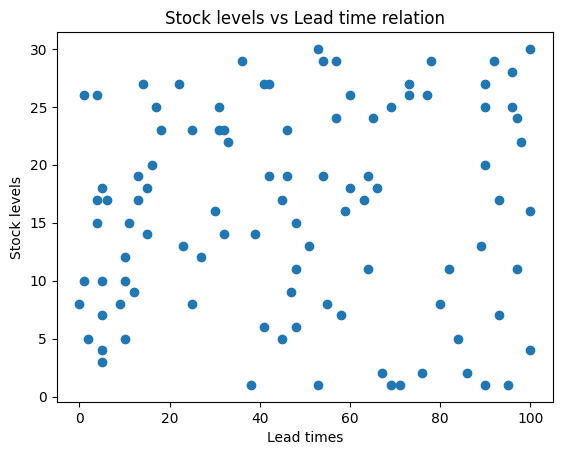

In [63]:
plt.scatter(df ['Stock levels'], df ['Lead times'])
plt.ylabel('Stock levels')
plt.xlabel('Lead times')
plt.title('Stock levels vs Lead time relation')
plt.show()

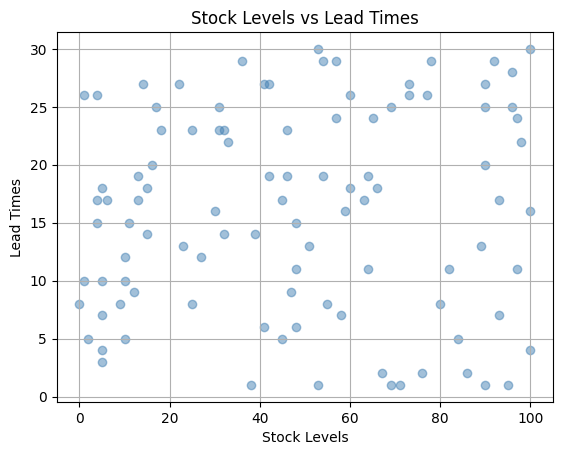

In [64]:
plt.scatter(df['Stock levels'], df['Lead times'], alpha=0.5, color='steelblue')
plt.xlabel('Stock Levels')
plt.ylabel('Lead Times')
plt.title('Stock Levels vs Lead Times')
plt.grid(True)
plt.show()

# **Which transportation mode is cheapest?**

In [65]:
cheapest_mode = df.groupby('Transportation modes')['Costs'].sum().sort_values(ascending=False).head()

In [66]:
print(cheapest_mode)

Transportation modes
Road    16048.193639
Rail    15168.931559
Air     14604.527498
Sea      7102.925520
Name: Costs, dtype: float64


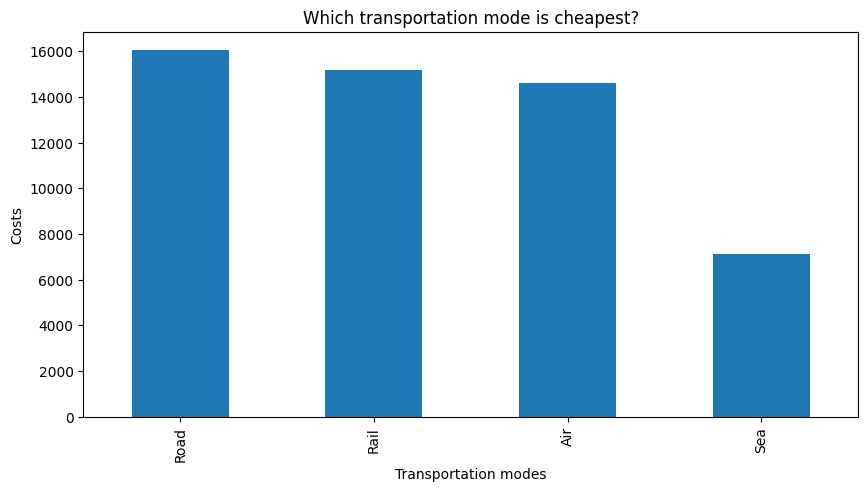

In [68]:
cheapest_mode.plot(kind='bar',figsize=(10,5),title='Which transportation mode is cheapest?')
plt.ylabel('Costs')
plt.xlabel('Transportation modes')
plt.show()

# **Defect rate vs Inspection results**

In [79]:
Defect_rate_vs_Inspection_results = df.groupby('Inspection results')['Defect rates'].sum().sort_values(ascending=False).head()

In [80]:
print(Defect_rate_vs_Inspection_results)

Inspection results
Fail       92.494877
Pending    88.322929
Pass       46.897993
Name: Defect rates, dtype: float64


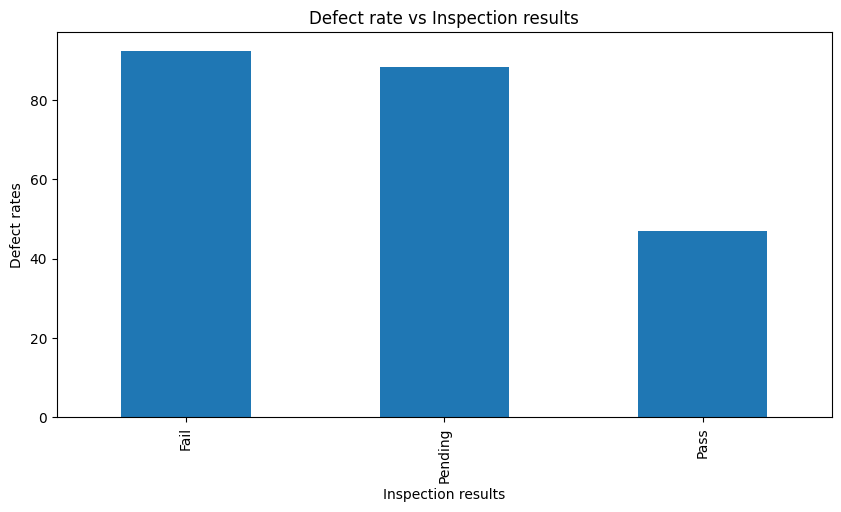

In [81]:
Defect_rate_vs_Inspection_results.plot(kind='bar',figsize=(10,5),title='Defect rate vs Inspection results')
plt.ylabel('Defect rates')
plt.xlabel('Inspection results')
plt.show()


# **ML Model:  Predict Defect Rate**

In [117]:
X = df[['Manufacturing costs', 'Production volumes', 'Lead time', 'Shipping costs','Order quantities', 'Price', 'Availability']]
y = df['Revenue generated']

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [120]:
from sklearn.ensemble import RandomForestRegressor

In [121]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [122]:
y_pred = model.predict(X_test)

In [123]:
from sklearn.metrics import r2_score,mean_absolute_error

In [124]:
print('R2_SCORE',r2_score(y_test,y_pred))
print('Mean Absolute Error',mean_absolute_error(y_test,y_pred))

R2_SCORE -0.17791923177649127
Mean Absolute Error 2742.3556106850456


In [125]:
print(df.corr(numeric_only=True))

                            Price  Availability  Number of products sold  \
Price                    1.000000      0.019083                 0.005739   
Availability             0.019083      1.000000                 0.087496   
Number of products sold  0.005739      0.087496                 1.000000   
Revenue generated        0.038424     -0.075170                -0.001641   
Stock levels             0.078261     -0.025900                 0.022189   
Lead times               0.044855      0.170439                -0.046419   
Order quantities         0.095819      0.143769                 0.015992   
Shipping times           0.071942     -0.051377                 0.087315   
Shipping costs           0.058543     -0.044179                 0.044285   
Lead time                0.152185     -0.156669                 0.041230   
Production volumes      -0.124575      0.050134                 0.187945   
Manufacturing lead time -0.301313      0.065333                -0.048939   
Manufacturin

# ** ML Model Observations**
Correlation analysis was performed to identify relationships between features and target variables.

All features showed weak correlation with Revenue Generated and Defect Rates (max correlation: -0.21).

This indicates the dataset is synthetically generated with no strong underlying patterns.

Due to weak feature relationships, Regression and Classification models performed poorly:
- Random Forest Regressor: R2 Score = -1.22 (negative, worse than baseline)
- Random Forest Classifier: Accuracy = 55% (close to random guess)

**Conclusion:** Real-world supply chain data with stronger feature relationships would significantly improve model performance.